In [7]:
import importlib
import FTransform.fuzzy_transform as ftmodule

importlib.reload(ftmodule)

from FTransform.fuzzy_transform import FuzzyTransformND
print(
    hasattr(
        FuzzyTransformND,
        "compute_statistical_characteristics"
    )
)

True



1D synthetic example
       group variable  n_obs  n_components_supported   df_eff  df_residual_trace   sigma2  pseudo_R2  local_R2  partition_max_abs_error
synthetic_1d        y    180                       7 4.640472         174.261063 0.205939   0.736205  0.399146                      0.0

1D RMSE relative to true f: 0.35110366307736124
1D MAE relative to true f: 0.2640299380759004


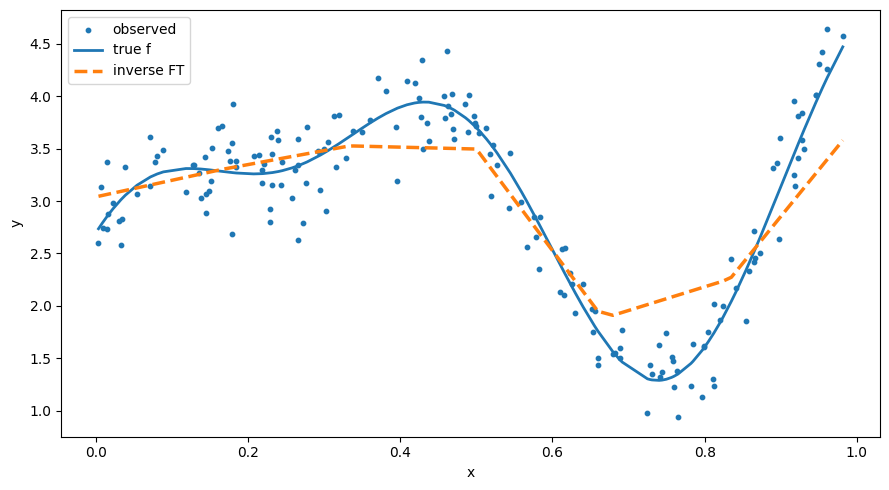

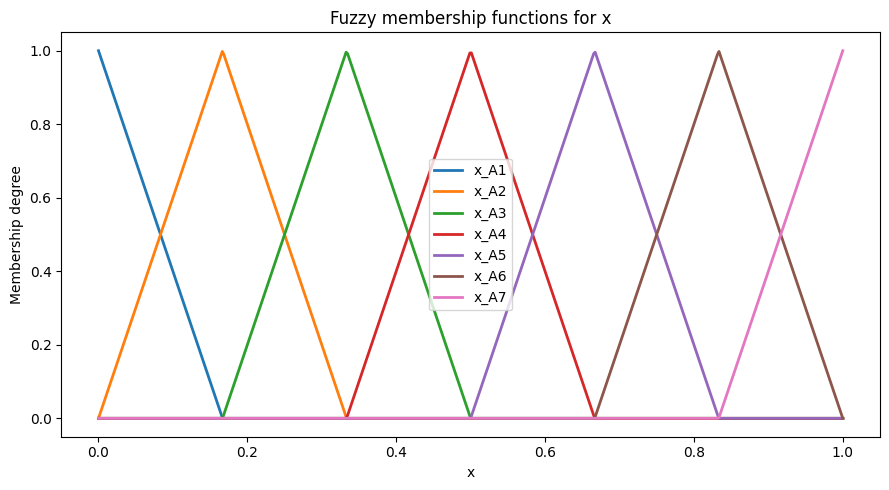


1D FT component inference:
component    value       SE   t_value       p_value  ci_lower  ci_upper
    C_xA1 3.040653 0.100296 30.316798  2.116194e-71  2.842702  3.238604
    C_xA2 3.304115 0.063462 52.064332 3.866366e-108  3.178862  3.429368
    C_xA3 3.526734 0.065062 54.205392 5.173211e-111  3.398322  3.655145
    C_xA4 3.496611 0.069073 50.621913 3.823471e-106  3.360284  3.632939
    C_xA5 1.880513 0.070962 26.500433  5.014305e-63  1.740458  2.020568
    C_xA6 2.256760 0.067322 33.521943  6.727787e-78  2.123889  2.389631
    C_xA7 3.743811 0.098745 37.913837  4.259858e-86  3.548921  3.938702

1D local slope inference:
 segment  from_node  to_node     slope       SE   t_value  p_value   ci_lower  ci_upper
A1_to_A2   0.000000 0.166667  1.580772 4.245014  0.372383 0.710048  -6.795937  9.957481
A2_to_A3   0.166667 0.333333  1.335711 3.461364  0.385892 0.700035  -5.494617  8.166040
A3_to_A4   0.333333 0.500000 -0.180734 3.853631 -0.046900 0.962645  -7.785125  7.423657
A4_to_A5   0.5000

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# If the class is stored in another file, uncomment:
# from fuzzy_transform import FuzzyTransformND


# ============================================================
# Utility functions
# ============================================================

def rmse(y, yhat):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    return np.sqrt(np.mean((y - yhat) ** 2))


def mae(y, yhat):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    return np.mean(np.abs(y - yhat))


def print_model_summary(results, title):
    """
    Print selected global FT characteristics.
    """

    model = results["model"]

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    cols = [
        "group",
        "variable",
        "n_obs",
        "n_components_supported",
        "df_eff",
        "df_residual_trace",
        "sigma2",
        "pseudo_R2",
        "local_R2",
        "partition_max_abs_error",
    ]

    existing = [c for c in cols if c in model.columns]

    print(model[existing].to_string(index=False))


# ============================================================
# 1. ONE-DIMENSIONAL ARTIFICIAL EXAMPLE
# ============================================================

def generate_1d_data(
    n=180,
    noise_sd=0.25,
    seed=123
):
    """
    Smooth nonlinear 1D regression problem.

    x in [0,1].

    True function:
        f(x) =
        2 + 1.5 sin(2 pi x)
          + 0.7 cos(4 pi x)
          + 2x
    """

    rng = np.random.default_rng(seed)

    x = np.sort(
        rng.uniform(0, 1, size=n)
    )

    true = (
        2
        + 1.5 * np.sin(2 * np.pi * x)
        + 0.7 * np.cos(4 * np.pi * x)
        + 2.0 * x
    )

    y = (
        true
        + rng.normal(
            0,
            noise_sd,
            size=n
        )
    )

    data = pd.DataFrame({
        "x": x,
        "y": y,
        "true": true,

        # one group
        "file": "synthetic_1d",

        # Each observation is independent here
        "name": [
            f"P{i+1:03d}"
            for i in range(n)
        ],
    })

    return data


# ------------------------------------------------------------
# Generate data
# ------------------------------------------------------------

data_1d = generate_1d_data()


# ------------------------------------------------------------
# Define FT
# ------------------------------------------------------------

ft_1d = FuzzyTransformND(
    input_cols=["x"],
    n_sets=7,
    group_col="file",
    input_mins={"x": 0.0},
    input_maxs={"x": 1.0},
)


# ------------------------------------------------------------
# Fit fuzzy partition
# ------------------------------------------------------------

ft_1d.fit_partition(data_1d)


# ------------------------------------------------------------
# Statistical characteristics
# ------------------------------------------------------------

stats_1d = ft_1d.compute_statistical_characteristics(
    data=data_1d,
    value_cols=["y"],
    alpha=0.05,
    variance_df="smoother_residual_trace",
)


print_model_summary(
    stats_1d,
    "1D synthetic example"
)


# ------------------------------------------------------------
# Retrieve fitted inverse FT
# ------------------------------------------------------------

fit_1d = (
    stats_1d["fitted"]
    .sort_values("original_index")
)

data_1d_plot = data_1d.copy()

data_1d_plot["fit"] = (
    fit_1d["fitted"].to_numpy()
)


# ------------------------------------------------------------
# Accuracy relative to known true function
# ------------------------------------------------------------

print("\n1D RMSE relative to true f:",
      rmse(
          data_1d_plot["true"],
          data_1d_plot["fit"]
      ))

print(
    "1D MAE relative to true f:",
    mae(
        data_1d_plot["true"],
        data_1d_plot["fit"]
    )
)


# ------------------------------------------------------------
# Save exactly the columns needed by PGFPlots/TikZ
# ------------------------------------------------------------

data_1d_plot[
    ["x", "y", "true", "fit"]
].to_csv(
    "regdata_1d.csv",
    index=False
)


# ------------------------------------------------------------
# Plot in Python as a quick check
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.scatter(
    data_1d_plot["x"],
    data_1d_plot["y"],
    s=10,
    label="observed"
)

plt.plot(
    data_1d_plot["x"],
    data_1d_plot["true"],
    linewidth=2,
    label="true f"
)

plt.plot(
    data_1d_plot["x"],
    data_1d_plot["fit"],
    linewidth=2.5,
    linestyle="--",
    label="inverse FT"
)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Show fuzzy membership functions
# ------------------------------------------------------------

ft_1d.plot_memberships("x")


# ============================================================
# 1D COMPONENT STATISTICS
# ============================================================

component_stats_1d = stats_1d["components"]

print("\n1D FT component inference:")

print(
    component_stats_1d[
        [
            "component",
            "value",
            "SE",
            "t_value",
            "p_value",
            "ci_lower",
            "ci_upper",
        ]
    ].to_string(index=False)
)


# ============================================================
# 1D LOCAL SLOPES
# ============================================================

slopes_1d = ft_1d.segment_inference(
    data=data_1d,
    value_cols=["y"],
    along_col="x",
    subject_col="name",
)

print("\n1D local slope inference:")

print(
    slopes_1d[
        [
            "segment",
            "from_node",
            "to_node",
            "slope",
            "SE",
            "t_value",
            "p_value",
            "ci_lower",
            "ci_upper",
        ]
    ].to_string(index=False)
)






In [13]:
# ============================================================
# 1D SYNTHETIC DATA -- GENERATED ONLY ONCE
# ============================================================

rng = np.random.default_rng(12345)

n_obs = 180
sigma_true = 0.25
sigma2_true = sigma_true**2

x = np.sort(rng.uniform(0.0, 1.0, size=n_obs))

true_f = (
    2.0
    + 1.5 * np.sin(2.0 * np.pi * x)
    + 0.7 * np.cos(4.0 * np.pi * x)
    + 2.0 * x
)

y = true_f + rng.normal(
    loc=0.0,
    scale=sigma_true,
    size=n_obs,
)

data_1d = pd.DataFrame(
    {
        "file": "synthetic_1d",
        "name": [f"P{i+1:03d}" for i in range(n_obs)],
        "x": x,
        "y": y,
        "true": true_f,
    }
)

# ============================================================
# NUMBER OF FUZZY SETS TO COMPARE
# ============================================================

n_sets_values = [4, 5, 7, 10, 15, 20]

results = []


# ============================================================
# REPEAT THE SAME EXPERIMENT FOR EACH NUMBER OF FUZZY SETS
# ============================================================

for n_sets in n_sets_values:

    print(f"Running n_sets = {n_sets} ...")

    # --------------------------------------------------------
    # Construct FT
    # --------------------------------------------------------

    ft = FuzzyTransformND(
        input_cols=["x"],
        n_sets=n_sets,
        group_col="file",
        input_mins={"x": 0.0},
        input_maxs={"x": 1.0},
    )

    ft.fit_partition(data_1d)

    # --------------------------------------------------------
    # Statistical characteristics
    # --------------------------------------------------------

    stats = ft.compute_statistical_characteristics(
        data=data_1d,
        value_cols=["y"],
        alpha=0.05,
        variance_df="smoother_residual_trace",
    )

    model = stats["model"].iloc[0]

    # --------------------------------------------------------
    # Obtain the smoothing matrix S
    #
    # There is only one group and one response variable here,
    # so there is only one smoothing matrix.
    # --------------------------------------------------------

    S = next(iter(stats["smoothing_matrices"].values()))

    # inverse FT at the observed x-values
    y_fit = S @ data_1d["y"].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Error relative to the KNOWN TRUE regression function
    # --------------------------------------------------------

    f_true = data_1d["true"].to_numpy(dtype=float)

    rmse_true = np.sqrt(
        np.mean((y_fit - f_true) ** 2)
    )

    mae_true = np.mean(
        np.abs(y_fit - f_true)
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append(
        {
            "n_sets": n_sets,

            # Effective degrees of freedom
            "tr_S": float(model["df_eff"]),

            # Residual-trace df
            "df_residual_trace":
                float(model["df_residual_trace"]),

            # Estimated noise/residual variance
            "sigma2_hat": float(model["sigma2"]),

            # True simulation variance -- useful for comparison
            "sigma2_true": sigma2_true,

            # Approximation error relative to true f
            "RMSE_true_f": rmse_true,
            "MAE_true_f": mae_true,

            # Goodness-of-fit measures
            "pseudo_R2": float(model["pseudo_R2"]),
            "local_R2": float(model["local_R2"]),

            # Numerical validation
            "partition_error":
                float(model["partition_max_abs_error"]),
        }
    )


# ============================================================
# RESULT TABLE
# ============================================================

comparison_1d = pd.DataFrame(results)

print("\n")
print("=" * 90)
print("1D comparison across different numbers of fuzzy sets")
print("=" * 90)

print(
    comparison_1d[
        [
            "n_sets",
            "tr_S",
            "RMSE_true_f",
            "sigma2_hat",
            "sigma2_true",
            "pseudo_R2",
            "local_R2",
        ]
    ].to_string(
        index=False,
        float_format=lambda z: f"{z:.6f}",
    )
)


# ============================================================
# SAVE FOR LATEX / FURTHER ANALYSIS
# ============================================================

comparison_1d.to_csv(
    "comparison_1d_nsets.csv",
    index=False,
)

print("\nSaved as: comparison_1d_nsets.csv")

Running n_sets = 4 ...
Running n_sets = 5 ...
Running n_sets = 7 ...
Running n_sets = 10 ...
Running n_sets = 15 ...
Running n_sets = 20 ...


1D comparison across different numbers of fuzzy sets
 n_sets      tr_S  RMSE_true_f  sigma2_hat  sigma2_true  pseudo_R2  local_R2
      4  2.660901     0.612732    0.508542     0.062500   0.388239  0.166041
      5  3.367318     0.451804    0.321244     0.062500   0.615489  0.338684
      7  4.713266     0.326644    0.206354     0.062500   0.755338  0.425466
     10  6.630122     0.156468    0.101872     0.062500   0.880888  0.522724
     15  9.799841     0.101733    0.075590     0.062500   0.913630  0.439979
     20 12.989580     0.085399    0.068541     0.062500   0.923498  0.340715

Saved as: comparison_1d_nsets.csv


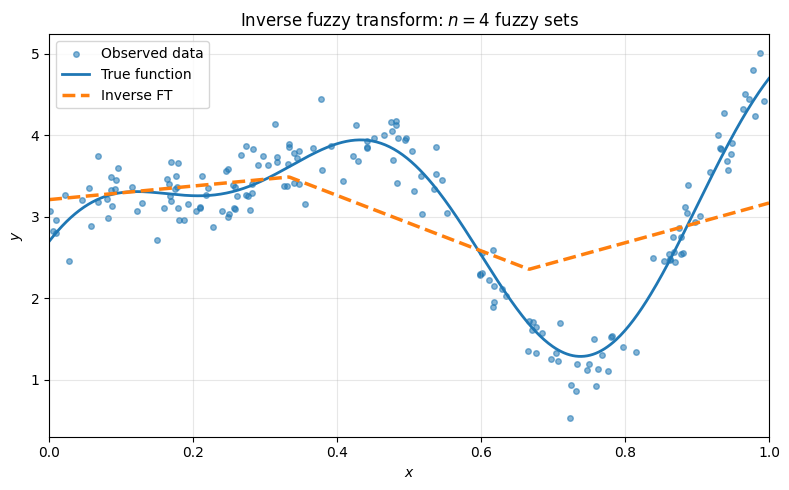

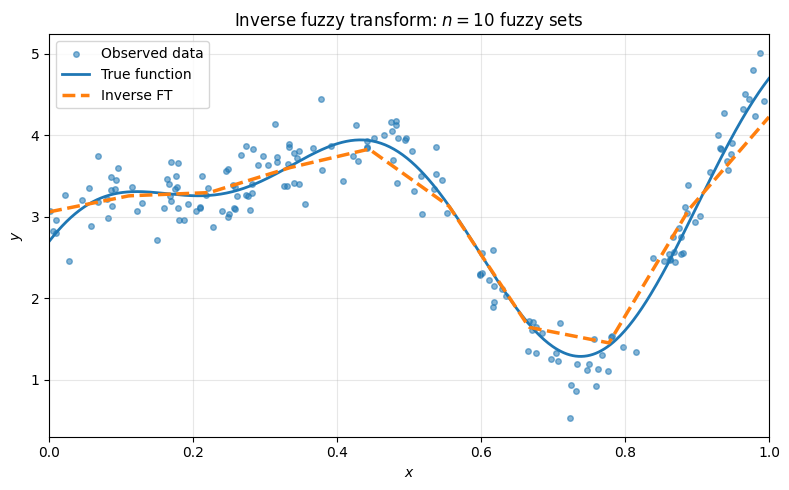

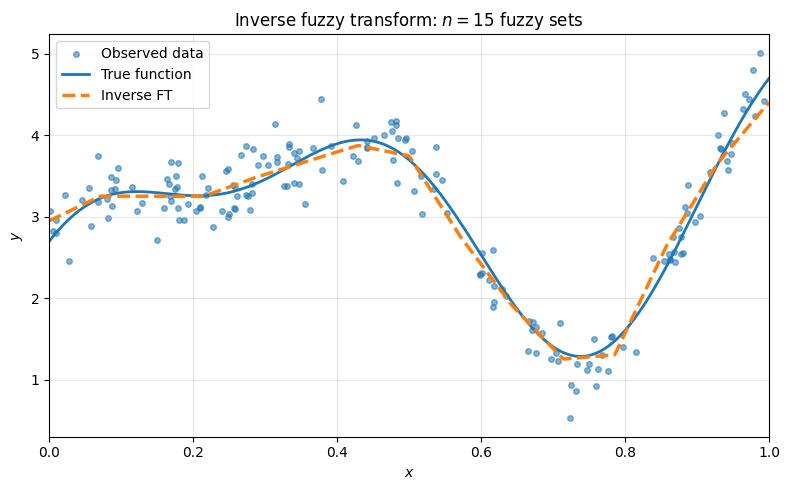

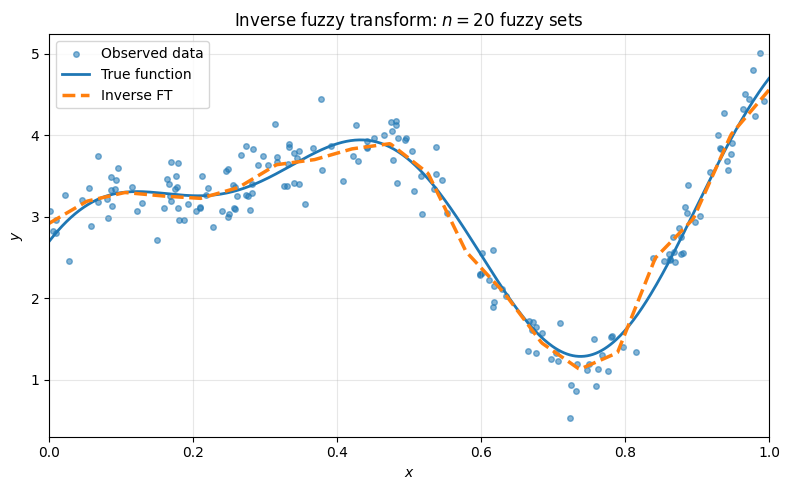

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from FTransform.fuzzy_transform import FuzzyTransformND


# ============================================================
# ASSUMES data_1d ALREADY EXISTS FROM THE PREVIOUS EXPERIMENT
#
# columns:
#   file
#   name
#   x
#   y
#   true
# ============================================================

n_sets_to_plot = [4, 10, 15, 20]

# Dense grid for smooth inverse FT
x_grid = np.linspace(0.0, 1.0, 500)

grid = pd.DataFrame({
    "x": x_grid
})


# ============================================================
# TRUE FUNCTION ON THE DENSE GRID
# ============================================================

true_grid = (
    2.0
    + 1.5 * np.sin(2.0 * np.pi * x_grid)
    + 0.7 * np.cos(4.0 * np.pi * x_grid)
    + 2.0 * x_grid
)


# ============================================================
# COMMON Y-LIMITS
# so all figures can be compared directly
# ============================================================

y_min = min(
    data_1d["y"].min(),
    true_grid.min()
)

y_max = max(
    data_1d["y"].max(),
    true_grid.max()
)

margin = 0.05 * (y_max - y_min)

y_limits = (
    y_min - margin,
    y_max + margin
)


# ============================================================
# FIT AND PLOT
# ============================================================

inverse_results = {}

for n_sets in n_sets_to_plot:

    # --------------------------------------------------------
    # Fit fuzzy partition
    # --------------------------------------------------------

    ft = FuzzyTransformND(
        input_cols=["x"],
        n_sets=n_sets,
        group_col="file",
        input_mins={"x": 0.0},
        input_maxs={"x": 1.0},
    )

    ft.fit_partition(data_1d)

    # --------------------------------------------------------
    # Direct F-transform
    # --------------------------------------------------------

    components = ft.compute_components(
        data=data_1d,
        value_cols=["y"],
    )

    # --------------------------------------------------------
    # Inverse F-transform on dense grid
    # --------------------------------------------------------

    inverse = ft.inverse_transform(
        component_table=components,
        grid=grid,
    )

    inverse_results[n_sets] = inverse.copy()

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    # observed noisy data
    plt.scatter(
        data_1d["x"],
        data_1d["y"],
        s=16,
        alpha=0.55,
        label="Observed data",
    )

    # true regression function
    plt.plot(
        x_grid,
        true_grid,
        linewidth=2,
        label="True function",
    )

    # inverse FT
    plt.plot(
        inverse["x"],
        inverse["fuzzy_value"],
        linewidth=2.5,
        linestyle="--",
        label="Inverse FT",
    )

    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")

    plt.title(
        rf"Inverse fuzzy transform: $n={n_sets}$ fuzzy sets"
    )

    plt.xlim(0.0, 1.0)
    plt.ylim(y_limits)

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()

    # optional: save figure
    plt.savefig(
        f"inverse_ft_n{n_sets}.pdf",
        bbox_inches="tight",
    )

    plt.show()

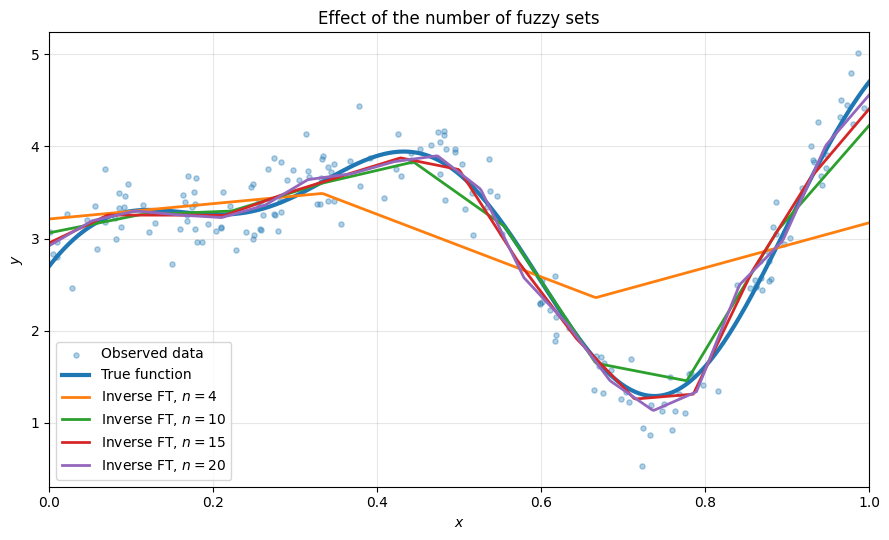

In [15]:
plt.figure(figsize=(9, 5.5))

# Observed data
plt.scatter(
    data_1d["x"],
    data_1d["y"],
    s=14,
    alpha=0.35,
    label="Observed data",
)

# True function
plt.plot(
    x_grid,
    true_grid,
    linewidth=3,
    label="True function",
)

# All inverse FT curves
for n_sets in n_sets_to_plot:

    inverse = inverse_results[n_sets]

    plt.plot(
        inverse["x"],
        inverse["fuzzy_value"],
        linewidth=2,
        label=rf"Inverse FT, $n={n_sets}$",
    )

plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

plt.title("Effect of the number of fuzzy sets")

plt.xlim(0.0, 1.0)
plt.ylim(y_limits)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "inverse_ft_comparison.pdf",
    bbox_inches="tight",
)

plt.show()


2D Branin benchmark
    group variable  n_obs  n_components_supported    df_eff  df_residual_trace     sigma2  pseudo_R2  local_R2  partition_max_abs_error
branin_2d        y    500                      36 16.015708           477.3821 229.210964   0.921429  0.634522             2.220446e-16

2D Branin RMSE relative to true surface: 14.147537853225298


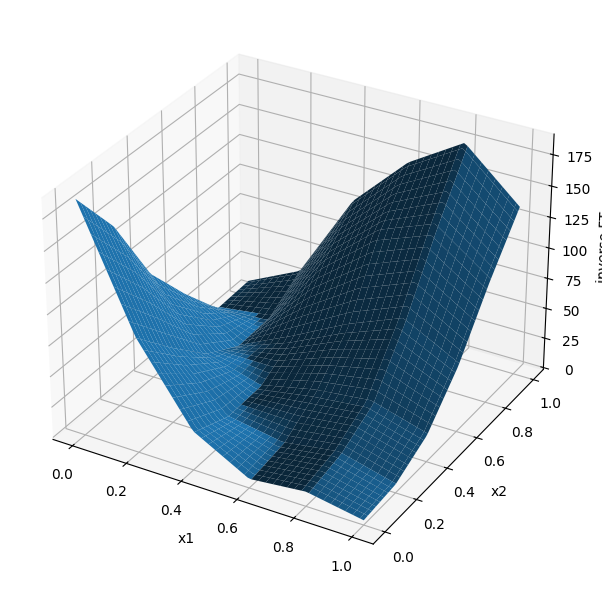


2D Branin slopes along x1:
 x2_component  segment  from_node  to_node       slope         SE      p_value     ci_lower    ci_upper
            1 A1_to_A2        0.0      0.2 -474.916027 295.017822 1.080766e-01 -1054.546213  104.714159
            1 A2_to_A3        0.2      0.4 -309.825615  87.592459 4.422539e-04  -481.921094 -137.730137
            1 A3_to_A4        0.4      0.6 -123.019303  39.559998 1.979892e-03  -200.743993  -45.294613
            1 A4_to_A5        0.6      0.8   22.545757  13.662366 9.952948e-02    -4.297095   49.388610
            1 A5_to_A6        0.8      1.0  -40.617180  17.135702 1.815164e-02   -74.284198   -6.950162
            2 A1_to_A2        0.0      0.2 -419.594739 185.833774 2.438294e-02  -784.707816  -54.481661
            2 A2_to_A3        0.2      0.4 -213.937396  41.196085 3.016576e-07  -294.876556 -132.998236
            2 A3_to_A4        0.4      0.6  -39.217065  17.554546 2.592451e-02   -73.706998   -4.727132
            2 A4_to_A5        0.6   

In [11]:
# ============================================================
# 2. TWO-DIMENSIONAL BRANIN BENCHMARK
# ============================================================

def branin_normalized(x1, x2):
    """
    Branin function using inputs x1,x2 in [0,1].

    The normalized inputs are transformed to the standard
    Branin domain:

        z1 in [-5, 10]
        z2 in [0, 15]
    """

    z1 = -5 + 15 * x1
    z2 = 15 * x2

    a = 1.0
    b = 5.1 / (4 * np.pi ** 2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8 * np.pi)

    value = (
        a * (
            z2
            - b * z1 ** 2
            + c * z1
            - r
        ) ** 2
        + s
        * (1 - t)
        * np.cos(z1)
        + s
    )

    return value


def generate_branin_data(
    n=500,
    noise_sd=5.0,
    seed=456
):
    rng = np.random.default_rng(seed)

    x1 = rng.uniform(
        0,
        1,
        size=n
    )

    x2 = rng.uniform(
        0,
        1,
        size=n
    )

    true = branin_normalized(
        x1,
        x2
    )

    y = (
        true
        + rng.normal(
            0,
            noise_sd,
            size=n
        )
    )

    return pd.DataFrame({
        "x1": x1,
        "x2": x2,
        "y": y,
        "true": true,
        "file": "branin_2d",
        "name": [
            f"P{i+1:04d}"
            for i in range(n)
        ]
    })


# ------------------------------------------------------------
# Generate Branin data
# ------------------------------------------------------------

data_2d = generate_branin_data()


# ------------------------------------------------------------
# Fit 2D tensor-product FT
# ------------------------------------------------------------

ft_2d = FuzzyTransformND(
    input_cols=[
        "x1",
        "x2"
    ],
    n_sets={
        "x1": 6,
        "x2": 6
    },
    group_col="file",
    input_mins={
        "x1": 0.0,
        "x2": 0.0
    },
    input_maxs={
        "x1": 1.0,
        "x2": 1.0
    },
)


ft_2d.fit_partition(
    data_2d
)


# ------------------------------------------------------------
# Compute statistical characteristics
# ------------------------------------------------------------

stats_2d = ft_2d.compute_statistical_characteristics(
    data=data_2d,
    value_cols=["y"],
    alpha=0.05,
    variance_df="smoother_residual_trace",
)


print_model_summary(
    stats_2d,
    "2D Branin benchmark"
)


# ============================================================
# 2D FITTED VALUES AT THE OBSERVED POINTS
# ============================================================

fit_2d_obs = (
    stats_2d["fitted"]
    .sort_values("original_index")
)

data_2d["fit"] = (
    fit_2d_obs["fitted"].to_numpy()
)


print(
    "\n2D Branin RMSE relative to true surface:",
    rmse(
        data_2d["true"],
        data_2d["fit"]
    )
)


# ============================================================
# 2D INVERSE FT ON A REGULAR GRID
# ============================================================

components_2d = ft_2d.compute_components(
    data=data_2d,
    value_cols=["y"]
)


grid_n = 80

x1_grid = np.linspace(
    0,
    1,
    grid_n
)

x2_grid = np.linspace(
    0,
    1,
    grid_n
)

X1, X2 = np.meshgrid(
    x1_grid,
    x2_grid,
    indexing="ij"
)


grid_2d = pd.DataFrame({
    "x1": X1.ravel(),
    "x2": X2.ravel()
})


inverse_grid_2d = ft_2d.inverse_transform(
    component_table=components_2d,
    grid=grid_2d
)


inverse_grid_2d = (
    inverse_grid_2d
    .loc[
        inverse_grid_2d["variable"]
        == "y"
    ]
    .copy()
)


inverse_grid_2d["true"] = (
    branin_normalized(
        inverse_grid_2d["x1"].to_numpy(),
        inverse_grid_2d["x2"].to_numpy()
    )
)


# Rename for easier TikZ use
inverse_grid_2d = inverse_grid_2d.rename(
    columns={
        "fuzzy_value": "fit"
    }
)


inverse_grid_2d[
    [
        "x1",
        "x2",
        "true",
        "fit"
    ]
].to_csv(
    "branin_surface.csv",
    index=False
)


# ============================================================
# 2D PYTHON SURFACE CHECK
# ============================================================

Z_fit = (
    inverse_grid_2d["fit"]
    .to_numpy()
    .reshape(
        grid_n,
        grid_n
    )
)


fig = plt.figure(
    figsize=(9, 6)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    X1,
    X2,
    Z_fit
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("inverse FT")

plt.tight_layout()
plt.show()


# ============================================================
# 2D LOCAL SLOPE INFERENCE
# ============================================================

# Slopes along x1 conditional on the fuzzy regions of x2

slopes_x1 = ft_2d.segment_inference(
    data=data_2d,
    value_cols=["y"],
    along_col="x1",
    subject_col="name"
)


print(
    "\n2D Branin slopes along x1:"
)

print(
    slopes_x1[
        [
            "x2_component",
            "segment",
            "from_node",
            "to_node",
            "slope",
            "SE",
            "p_value",
            "ci_lower",
            "ci_upper",
        ]
    ].head(20).to_string(index=False)
)


# Slopes along x2 conditional on x1

slopes_x2 = ft_2d.segment_inference(
    data=data_2d,
    value_cols=["y"],
    along_col="x2",
    subject_col="name"
)


In [9]:
# ============================================================
# 3. FIVE-DIMENSIONAL FRIEDMAN No. 1 BENCHMARK
# ============================================================

def friedman1_function(
    x1,
    x2,
    x3,
    x4,
    x5
):
    """
    Classical Friedman #1 regression function.

    f(x) =
        10 sin(pi x1 x2)
        + 20 (x3 - 0.5)^2
        + 10 x4
        + 5 x5

    with all inputs in [0,1].
    """

    return (
        10
        * np.sin(
            np.pi * x1 * x2
        )
        +
        20
        * (x3 - 0.5) ** 2
        +
        10 * x4
        +
        5 * x5
    )


def generate_friedman_data(
    n=600,
    noise_sd=1.0,
    seed=789
):
    rng = np.random.default_rng(seed)

    X = rng.uniform(
        0,
        1,
        size=(n, 5)
    )

    true = friedman1_function(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        X[:, 3],
        X[:, 4]
    )

    y = (
        true
        + rng.normal(
            0,
            noise_sd,
            size=n
        )
    )

    return pd.DataFrame({
        "x1": X[:, 0],
        "x2": X[:, 1],
        "x3": X[:, 2],
        "x4": X[:, 3],
        "x5": X[:, 4],
        "y": y,
        "true": true,
        "file": "friedman_5d",
        "name": [
            f"P{i+1:04d}"
            for i in range(n)
        ]
    })


# ------------------------------------------------------------
# Generate data
# ------------------------------------------------------------

data_5d = generate_friedman_data()


# ------------------------------------------------------------
# 5D FT
#
# 3 fuzzy sets per dimension:
#
#     3^5 = 243 possible tensor components
#
# which is still computationally manageable.
# ------------------------------------------------------------

ft_5d = FuzzyTransformND(
    input_cols=[
        "x1",
        "x2",
        "x3",
        "x4",
        "x5"
    ],
    n_sets={
        "x1": 3,
        "x2": 3,
        "x3": 3,
        "x4": 3,
        "x5": 3
    },
    group_col="file",
    input_mins={
        "x1": 0.0,
        "x2": 0.0,
        "x3": 0.0,
        "x4": 0.0,
        "x5": 0.0
    },
    input_maxs={
        "x1": 1.0,
        "x2": 1.0,
        "x3": 1.0,
        "x4": 1.0,
        "x5": 1.0
    },
)


ft_5d.fit_partition(
    data_5d
)


stats_5d = ft_5d.compute_statistical_characteristics(
    data=data_5d,
    value_cols=["y"],
    alpha=0.05,
    variance_df="smoother_residual_trace",
)


print_model_summary(
    stats_5d,
    "5D Friedman #1 benchmark"
)


# ------------------------------------------------------------
# Prediction accuracy at observed points
# ------------------------------------------------------------

fit_5d = (
    stats_5d["fitted"]
    .sort_values("original_index")
)


data_5d["fit"] = (
    fit_5d["fitted"].to_numpy()
)


print(
    "\n5D Friedman RMSE relative to true f:",
    rmse(
        data_5d["true"],
        data_5d["fit"]
    )
)

print(
    "5D Friedman MAE relative to true f:",
    mae(
        data_5d["true"],
        data_5d["fit"]
    )
)


# ============================================================
# TEST IMPORTANT MATHEMATICAL PROPERTIES
# ============================================================

def validate_ft(
    ft,
    results,
    data,
    label
):
    """
    Basic numerical checks corresponding to the theory.
    """

    print("\n" + "-" * 70)
    print("Validation:", label)
    print("-" * 70)

    # --------------------------------------------------------
    # 1. Partition of unity
    # --------------------------------------------------------

    data_A = ft.add_memberships(
        data
    )

    component_cols = (
        ft.component_table_[
            "component"
        ].tolist()
    )

    A_sum = (
        data_A[
            component_cols
        ]
        .sum(axis=1)
        .to_numpy()
    )

    max_partition_error = np.max(
        np.abs(
            A_sum - 1
        )
    )

    print(
        "max |sum B_k(x) - 1| =",
        max_partition_error
    )


    # --------------------------------------------------------
    # 2. Smoothing matrix symmetry
    # --------------------------------------------------------

    for key, S in (
        results[
            "smoothing_matrices"
        ].items()
    ):

        symmetry_error = np.max(
            np.abs(
                S - S.T
            )
        )

        print(
            f"{key}: max |S-S^T| =",
            symmetry_error
        )


    # --------------------------------------------------------
    # 3. ANOVA decomposition with cross term
    # --------------------------------------------------------

    model = results[
        "model"
    ]

    for _, row in model.iterrows():

        error = (
            row["SST"]
            - row["SSE"]
            - row["SSR_naive"]
            - row["cross_term"]
        )

        print(
            "SST - SSE - SSR - C =",
            error
        )


    # --------------------------------------------------------
    # 4. Local reconstruction index
    # --------------------------------------------------------

    if "local_R2" in model.columns:

        print(
            "local R2:",
            model[
                "local_R2"
            ].to_numpy()
        )


    # --------------------------------------------------------
    # 5. Compare residual degrees of freedom
    # --------------------------------------------------------

    print(
        model[
            [
                "df_component_count",
                "df_effective",
                "df_residual_trace"
            ]
        ].to_string(index=False)
    )


# Run validation
validate_ft(
    ft_1d,
    stats_1d,
    data_1d,
    "1D example"
)

validate_ft(
    ft_2d,
    stats_2d,
    data_2d,
    "2D Branin"
)

validate_ft(
    ft_5d,
    stats_5d,
    data_5d,
    "5D Friedman"
)

d:\Documents\Python\FTInference\FTransform\fuzzy_transform.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[component_name] = weight
d:\Documents\Python\FTInference\FTransform\fuzzy_transform.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[component_name] = weight
d:\Documents\Python\FTInference\FTransform\fuzzy_transform.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on


5D Friedman #1 benchmark
      group variable  n_obs  n_components_supported    df_eff  df_residual_trace   sigma2  pseudo_R2  local_R2  partition_max_abs_error
friedman_5d        y    600                     243 30.640133         548.744251 6.388717   0.760551  0.459416             5.551115e-16

5D Friedman RMSE relative to true f: 2.233878343283532
5D Friedman MAE relative to true f: 1.8226388319084696

----------------------------------------------------------------------
Validation: 1D example
----------------------------------------------------------------------
max |sum B_k(x) - 1| = 0.0
('synthetic_1d', 'y'): max |S-S^T| = 6.938893903907228e-18
SST - SSE - SSR - C = -1.4210854715202004e-14
local R2: [0.39914552]
 df_component_count  df_effective  df_residual_trace
                173    175.359528         174.261063

----------------------------------------------------------------------
Validation: 2D Branin
----------------------------------------------------------------------

d:\Documents\Python\FTInference\FTransform\fuzzy_transform.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[component_name] = weight
d:\Documents\Python\FTInference\FTransform\fuzzy_transform.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[component_name] = weight
d:\Documents\Python\FTInference\FTransform\fuzzy_transform.py:153: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on